In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("Housing.csv")

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("rows and columns",df.shape)
df.info()

rows and columns (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
print("TARGET: price")
print("FEATURES:\n",df.columns.drop("price"))

TARGET: price
FEATURES:
 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [7]:
print("Missing values")
df.isnull().sum()

Missing values


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
print("Dupe Rows:")
df.duplicated().sum()

Dupe Rows:


np.int64(0)

In [9]:
print("Categorical col.:")
object_cols = df.select_dtypes(include="object").columns
print(object_cols)

Categorical col.:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [10]:
encoded=pd.get_dummies(df,drop_first=True)
encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [11]:
encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [12]:
#CHARTS :)

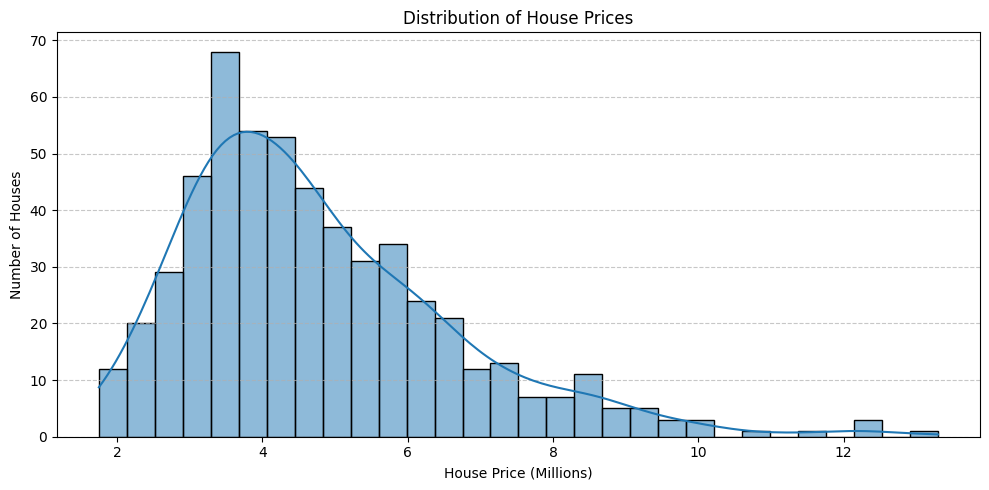

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["price"]/1000000,   
    bins=30,              
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (Millions)")
plt.ylabel("Number of Houses")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("charts/histogram.png")
plt.show()

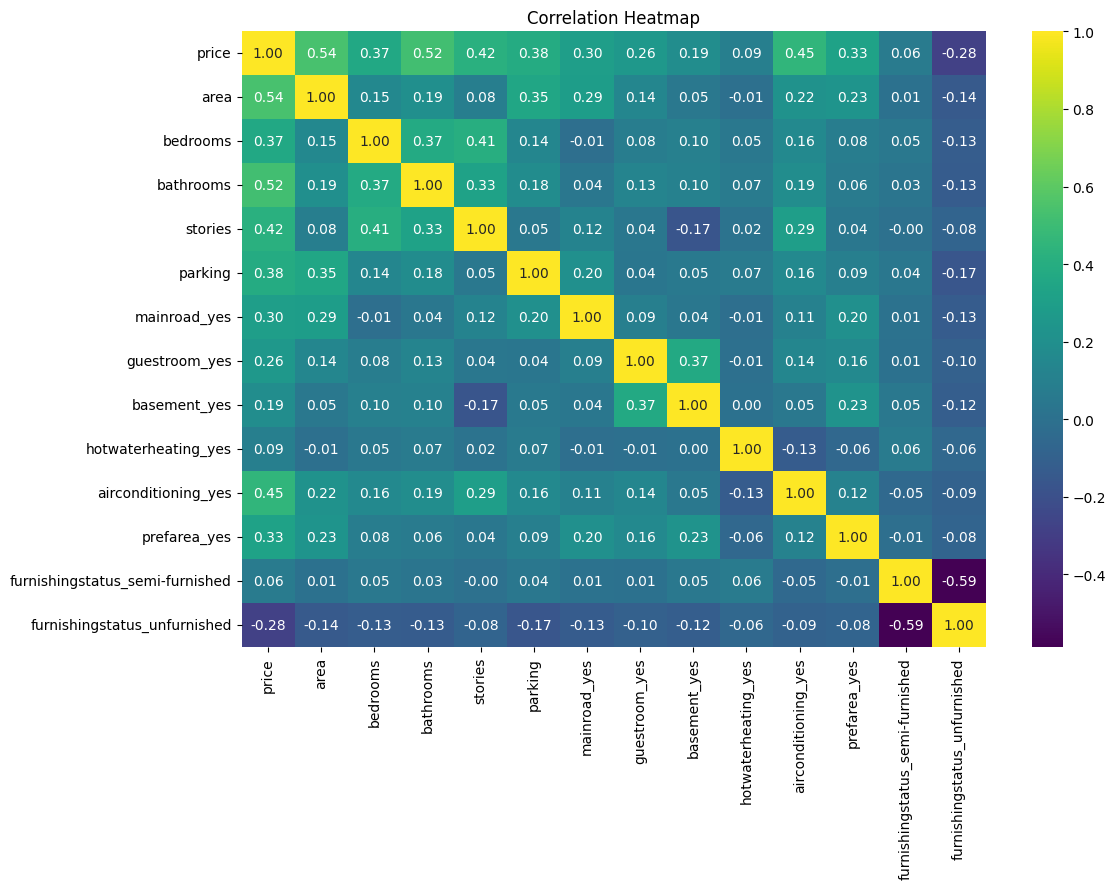

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    encoded.corr(),
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")
plt.show()

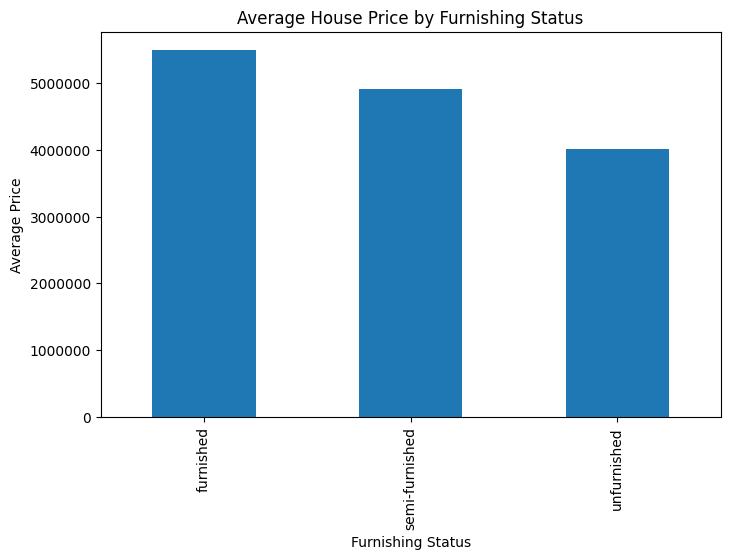

In [15]:
avg_price = df.groupby("furnishingstatus")["price"].mean()

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average House Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Price")

plt.ticklabel_format(style='plain', axis='y')
plt.savefig("charts/bar.png")
plt.show()

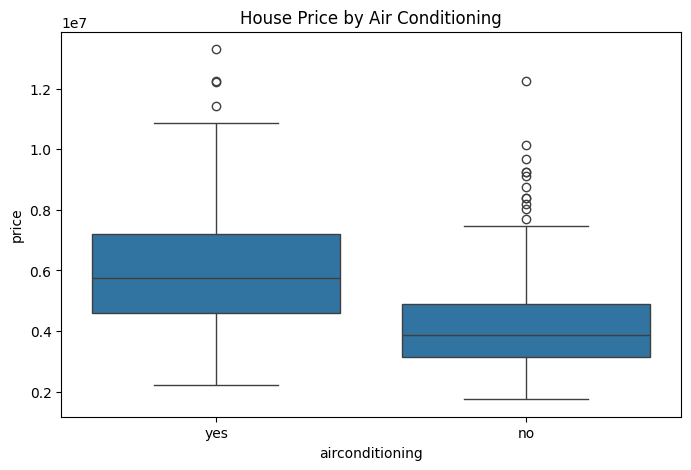

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="airconditioning",
    y="price",
    data=df
)

plt.title("House Price by Air Conditioning")
plt.savefig("charts/box.png")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

targ=encoded.drop("price", axis=1)
pred=encoded["price"]

x_train, x_test, y_train, y_test = train_test_split(
    targ,
    pred,
    test_size=0.2,
    random_state=42
)
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (436, 13)
x_test: (109, 13)
y_train: (436,)
y_test: (109,)


In [18]:
from sklearn.linear_model import LinearRegression
l=LinearRegression()
l.fit(x_train,y_train)

y_pred_l=l.predict(x_test)
comparison = pd.DataFrame({
    "Actual Price (Lakhs)": np.round(y_test / 100000, 2),
    "Predicted Price (Lakhs)": np.round(y_pred_l / 100000, 2)
})

comparison.head(10)


,Actual Price (Lakhs),Predicted Price (Lakhs)
316,40.60,51.65
77,66.50,72.25
360,37.10,31.10
90,64.40,46.12
493,28.00,32.95
209,49.00,35.32
176,52.50,56.12
249,45.43,63.68
516,24.50,27.23
426,33.53,26.29


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_l = mean_absolute_error(y_test, y_pred_l)
rmse_l= mean_squared_error(y_test, y_pred_l) ** 0.5
r2_l = r2_score(y_test, y_pred_l)

print("MAE for linear regression is", mae_l)
print("RMSE for linear regression is:", rmse_l)
print("R² Score for linear regression is:", r2_l)

MAE for linear regression is 970043.4039201637
RMSE for linear regression is: 1324506.9600914388
R² Score for linear regression is: 0.6529242642153184


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

rf_comparison = pd.DataFrame({
    "Actual Price (Lakhs)": np.round(y_test / 100000, 2),
    "Predicted Price (Lakhs)": np.round(y_pred_rf / 100000, 2)
})

rf_comparison.reset_index(drop=True, inplace=True)

rf_comparison.head(10)

,Actual Price (Lakhs),Predicted Price (Lakhs)
0,40.60,53.78
1,66.50,72.87
2,37.10,37.48
3,64.40,45.02
4,28.00,37.49
5,49.00,34.33
6,52.50,50.70
7,45.43,50.50
8,24.50,25.72
9,33.53,28.23


In [21]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE for random forest regressor:", mae_rf)
print("RMSE for random forest regressor:", rmse_rf)
print("R² Score for random forest regressor:", r2_rf)

MAE for random forest regressor: 1021546.0353211008
RMSE for random forest regressor: 1400565.9728553821
R² Score for random forest regressor: 0.611918531405699


In [22]:
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE (Lakhs)": [round(mae_l/100000,2), round(mae_rf/100000,2)],
    "RMSE (Lakhs)": [round(rmse_l/100000,2), round(rmse_rf/100000,2)],
    "R² Score": [round(r2_l,3), round(r2_rf,3)]
})

comparison_table

,Model,MAE (Lakhs),RMSE (Lakhs),R² Score
0,Linear Regression,9.70,13.25,0.653
1,Random Forest,10.22,14.01,0.612


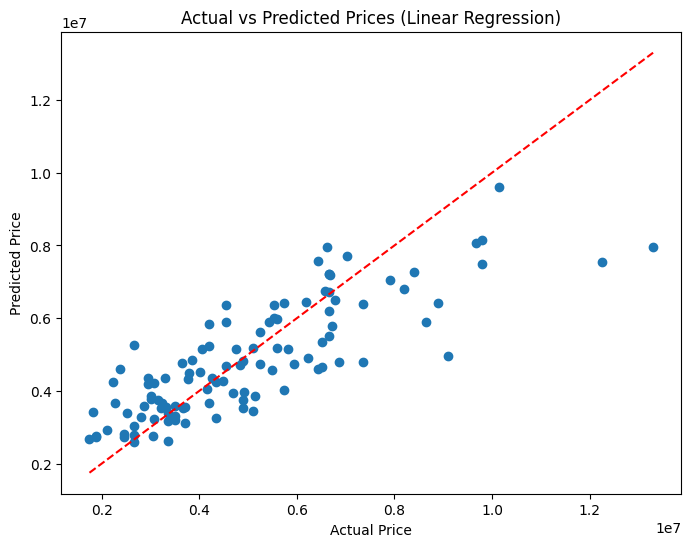

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_l)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices (Linear Regression)")

plt.savefig(
    "charts/actual_vs_predicted for linear regression.png",
)

plt.show()

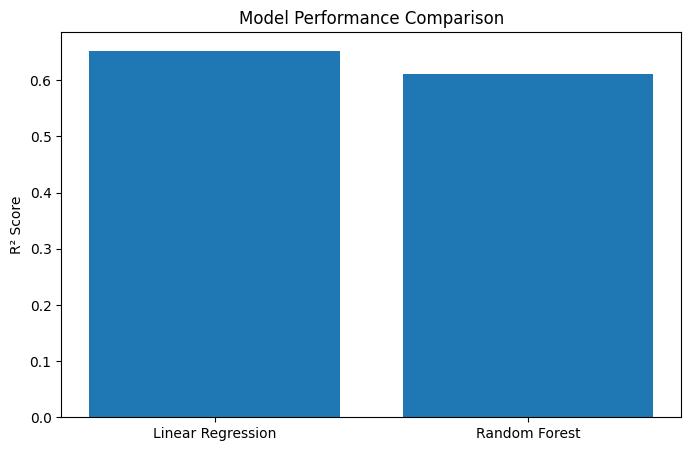

In [24]:
models = ["Linear Regression", "Random Forest"]
r2_scores = [r2_l, r2_rf]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.savefig(
    "charts/model_comparison.png"
)

plt.show()

INSIGHTS AND SUMMARY:
1. From the HeatMap visualizions earlier we found out that the area is one of the major factor which influences the price..so houses with larger areas are more priced
2. My Linear regression model was able to acheieve a R^2 score of 0.65. We can say that the model's predictions was a little off by 9.7 lakhs on avg also predictions werent perfectly accurate but it was able to identify and estimate house prices queit well
3. we usually use random forest regressor bcoz it provides better estimation and prediction but in our case of housing prices linear regression performed better and that was surprising
4. If real estate owners want profits they can focus on larger areas and also build and maintain more desirable amenities such as airconditioning parking facilities etc which attracts customers and increase property value.